C:\Users\amcna\AppData\Local\Temp\ipykernel_34272\613501268.py:23: RuntimeWarning: divide by zero encountered in log10
  curFft = 10*np.log10(curFft)        # Scale logarithmically
C:\Users\amcna\AppData\Local\Temp\ipykernel_34272\613501268.py:24: RuntimeWarning: invalid value encountered in divide
  curFft = curFft / (np.max(curFft))  # Normalize


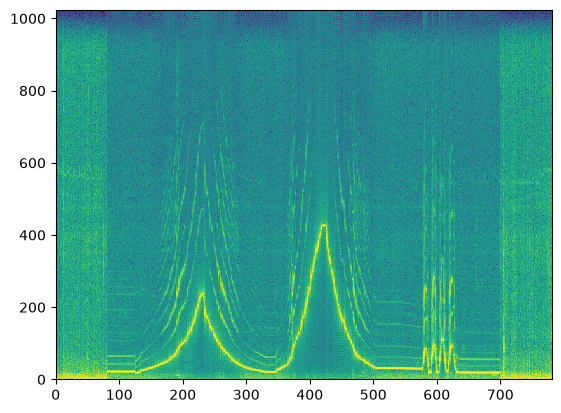

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read, write
from numpy.fft import fft, ifft

FRAME_SIZE = 1024
ZP_FACTOR = 2
FFT_SIZE = FRAME_SIZE * ZP_FACTOR


################## YOUR CODE HERE ######################
def ece420ProcessFrame(frame):
    curFft = np.zeros(FFT_SIZE)

    # apply hamming window to frame
    window = np.hamming(FRAME_SIZE)
    windowed_frame = frame*window
    curFft = np.fft.fft(windowed_frame, FFT_SIZE)
    # print("CURRFFT")
    # print(curFft)

    curFft = np.abs(curFft)             # Get the magnitude
    curFft = np.square(curFft)          # Square the magnitude
    curFft = 10*np.log10(curFft)        # Scale logarithmically  (might need to add epsilon)
    curFft = curFft / (np.max(curFft))  # Normalize
    
    return curFft[:FRAME_SIZE]


################# GIVEN CODE BELOW #####################

Fs, data = read('test_single_tones.wav')

numFrames = int(len(data) / FRAME_SIZE)
bmp = np.zeros((numFrames, FRAME_SIZE))

for i in range(numFrames):
    frame = data[i * FRAME_SIZE : (i + 1) * FRAME_SIZE]
    curFft = ece420ProcessFrame(frame)
    bmp[i, :] = curFft

plt.figure()
plt.pcolormesh(bmp.T, vmin=0, vmax=1)
plt.axis('tight')
plt.show()